# Final Results: Forecast Reliability in Electricity Load Forecasting

## Objective

This notebook presents the final results of the project analyzing forecast reliability in electricity load forecasting. The goal is to identify when forecasting models become unreliable under different temporal and operational conditions.

## Research Questions

1. Do forecast errors vary across temporal categories such as hour of day, day of week, and season?
2. Are forecast errors significantly higher during high-demand periods?
3. Does forecast reliability deteriorate during seasonal peak conditions?

## Methodology

A lag-1 persistence model is used as a baseline forecast, where the predicted value equals the previous hour's demand.

Absolute forecast error is calculated as:

Absolute Error = |Actual - Predicted|

Forecast errors are then analyzed across:
- hour of day
- day of week
- season
- demand regime

Statistical validation is performed using ANOVA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

In [2]:
# Load dataset
df = pd.read_csv("/content/PJME_hourly.csv")

# Clean column names just in case
df.columns = df.columns.str.strip()

df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


### Data Description

The dataset contains hourly electricity demand values for the PJM region. The main variable used in this analysis is `PJME_MW`, representing electricity load in megawatts.

In [3]:
# Convert Datetime column and set as index
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime").set_index("Datetime")

df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


### Data Preparation Explanation

The Datetime column is converted into a proper datetime format and used as the index to support time-series analysis. This allows time-based features such as hour, weekday, and season to be extracted accurately.

In [4]:
# Create lag-1 prediction
df["predicted"] = df["PJME_MW"].shift(1)

# Compute absolute forecast error
df["abs_error"] = (df["PJME_MW"] - df["predicted"]).abs()

# Remove the first missing row created by shift
df = df.dropna().copy()

df.head()

,PJME_MW,predicted,abs_error
Datetime,,,
2002-01-01 02:00:00,29265.0,30393.0,1128.0
2002-01-01 03:00:00,28357.0,29265.0,908.0
2002-01-01 04:00:00,27899.0,28357.0,458.0
2002-01-01 05:00:00,28057.0,27899.0,158.0
2002-01-01 06:00:00,28654.0,28057.0,597.0


### Forecast Construction

A lag-1 persistence model is used as a transparent baseline forecast. In this model, each predicted value is simply the previous hour's actual demand. Absolute forecast error is then computed to measure how far the forecast deviates from the actual value.

In [5]:
# Feature engineering
df["hour"] = df.index.hour
df["day_of_week"] = df.index.day_name()
df["month"] = df.index.month

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["season"] = df["month"].apply(get_season)

df["demand_category"] = pd.qcut(
    df["PJME_MW"],
    q=[0, 0.25, 0.75, 1],
    labels=["Low", "Normal", "High"]
)

df.head()

,PJME_MW,predicted,abs_error,hour,day_of_week,month,season,demand_category
Datetime,,,,,,,,
2002-01-01 02:00:00,29265.0,30393.0,1128.0,2,Tuesday,1,Winter,Normal
2002-01-01 03:00:00,28357.0,29265.0,908.0,3,Tuesday,1,Winter,Normal
2002-01-01 04:00:00,27899.0,28357.0,458.0,4,Tuesday,1,Winter,Normal
2002-01-01 05:00:00,28057.0,27899.0,158.0,5,Tuesday,1,Winter,Normal
2002-01-01 06:00:00,28654.0,28057.0,597.0,6,Tuesday,1,Winter,Normal


### Feature Engineering Explanation

Several derived variables are created to support grouped reliability analysis. These include hour of day, day of week, month, season, and demand regime. These features make it possible to compare forecast error across different temporal and operational conditions.

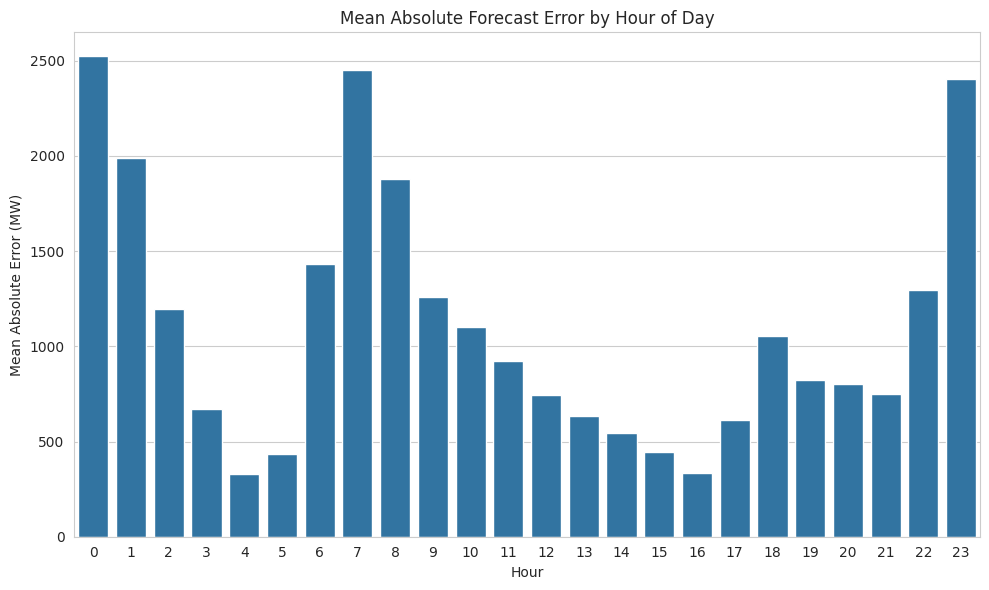

In [6]:
hourly_error = df.groupby("hour")["abs_error"].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=hourly_error, x="hour", y="abs_error")
plt.title("Mean Absolute Forecast Error by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Mean Absolute Error (MW)")
plt.tight_layout()
plt.show()

### Interpretation: Error by Hour

Forecast errors vary substantially across hours of the day. Higher error values are observed during peak demand periods such as early morning and late evening. This suggests that rapid shifts in electricity usage make forecasting more difficult during these hours.

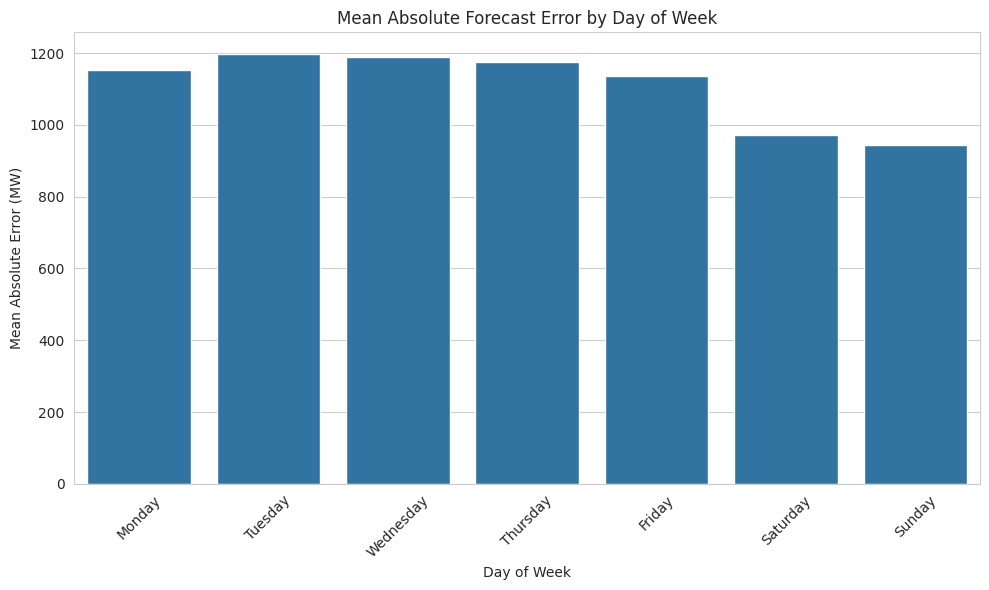

In [7]:
weekday_error = df.groupby("day_of_week")["abs_error"].mean().reset_index()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_error["day_of_week"] = pd.Categorical(
    weekday_error["day_of_week"],
    categories=weekday_order,
    ordered=True
)
weekday_error = weekday_error.sort_values("day_of_week")

plt.figure(figsize=(10, 6))
sns.barplot(data=weekday_error, x="day_of_week", y="abs_error")
plt.xticks(rotation=45)
plt.title("Mean Absolute Forecast Error by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Mean Absolute Error (MW)")
plt.tight_layout()
plt.show()

### Interpretation: Error by Day of Week

Forecast errors vary across days of the week, indicating that electricity demand behavior is not constant throughout the week. Weekdays generally show slightly higher error levels, likely due to increased industrial and commercial activity. This suggests that weekly demand structure affects forecast reliability.

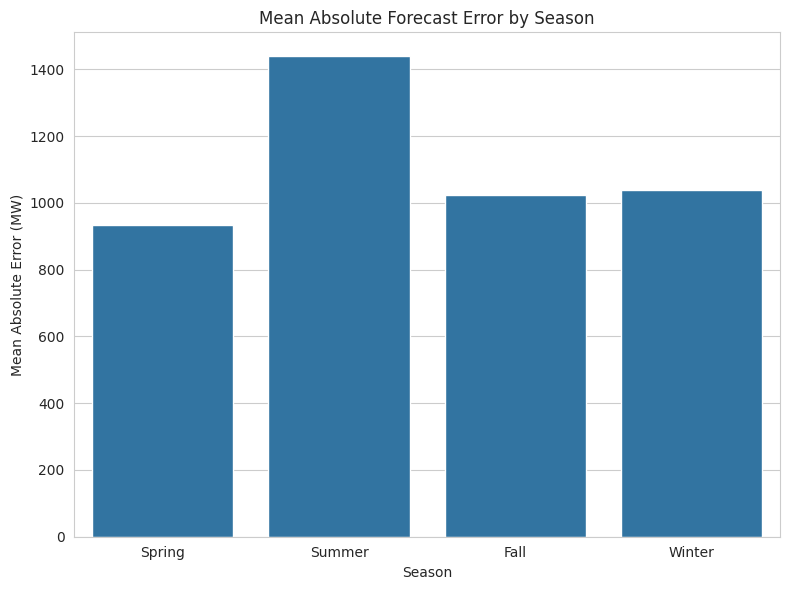

In [8]:
season_error = df.groupby("season")["abs_error"].mean().reset_index()

season_order = ["Spring", "Summer", "Fall", "Winter"]
season_error["season"] = pd.Categorical(
    season_error["season"],
    categories=season_order,
    ordered=True
)
season_error = season_error.sort_values("season")

plt.figure(figsize=(8, 6))
sns.barplot(data=season_error, x="season", y="abs_error")
plt.title("Mean Absolute Forecast Error by Season")
plt.xlabel("Season")
plt.ylabel("Mean Absolute Error (MW)")
plt.tight_layout()
plt.show()

### Interpretation: Error by Season

Forecast errors differ across seasons, with summer showing the highest error levels. This likely reflects greater volatility caused by cooling demand and sudden consumption spikes. The result indicates that seasonal conditions have a strong influence on forecast reliability.

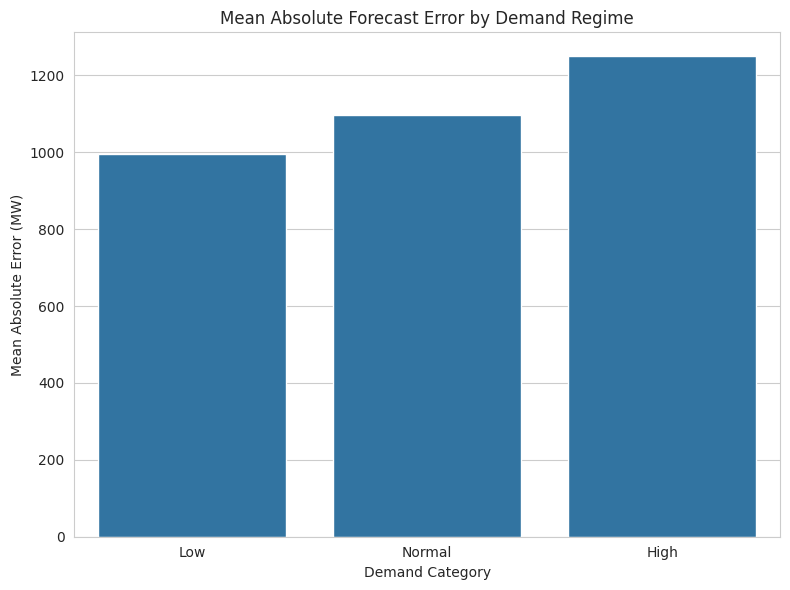

In [9]:
regime_error = df.groupby("demand_category", observed=False)["abs_error"].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=regime_error, x="demand_category", y="abs_error")
plt.title("Mean Absolute Forecast Error by Demand Regime")
plt.xlabel("Demand Category")
plt.ylabel("Mean Absolute Error (MW)")
plt.tight_layout()
plt.show()

### Interpretation: Error by Demand Regime

Forecast error increases as demand moves from low to high levels. This indicates that the model becomes less reliable during periods of elevated system stress. High-demand conditions are therefore a major source of forecasting instability.

## Statistical Validation

To verify whether the observed differences in forecast error are statistically meaningful, ANOVA is used. This helps determine whether differences across groups are likely due to real underlying variation rather than random chance.

In [10]:
# ANOVA for season
season_groups = [group["abs_error"].values for _, group in df.groupby("season")]
season_f, season_p = stats.f_oneway(*season_groups)

print("Season ANOVA F-statistic:", season_f)
print("Season ANOVA p-value:", season_p)

# ANOVA for demand regime
demand_groups = [group["abs_error"].values for _, group in df.groupby("demand_category")]
demand_f, demand_p = stats.f_oneway(*demand_groups)

print("Demand Regime ANOVA F-statistic:", demand_f)
print("Demand Regime ANOVA p-value:", demand_p)

Season ANOVA F-statistic: 2220.619074687171
Season ANOVA p-value: 0.0
Demand Regime ANOVA F-statistic: 694.2135972106878
Demand Regime ANOVA p-value: 8.662037647955253e-301


/tmp/ipykernel_7235/173386331.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demand_groups = [group["abs_error"].values for _, group in df.groupby("demand_category")]


### Interpretation: ANOVA Results

If the p-values are below 0.05, the differences in forecast error across groups are statistically significant. This confirms that the observed error variation across seasons and demand regimes is not due to random chance. In other words, forecast reliability is meaningfully affected by these operational conditions.

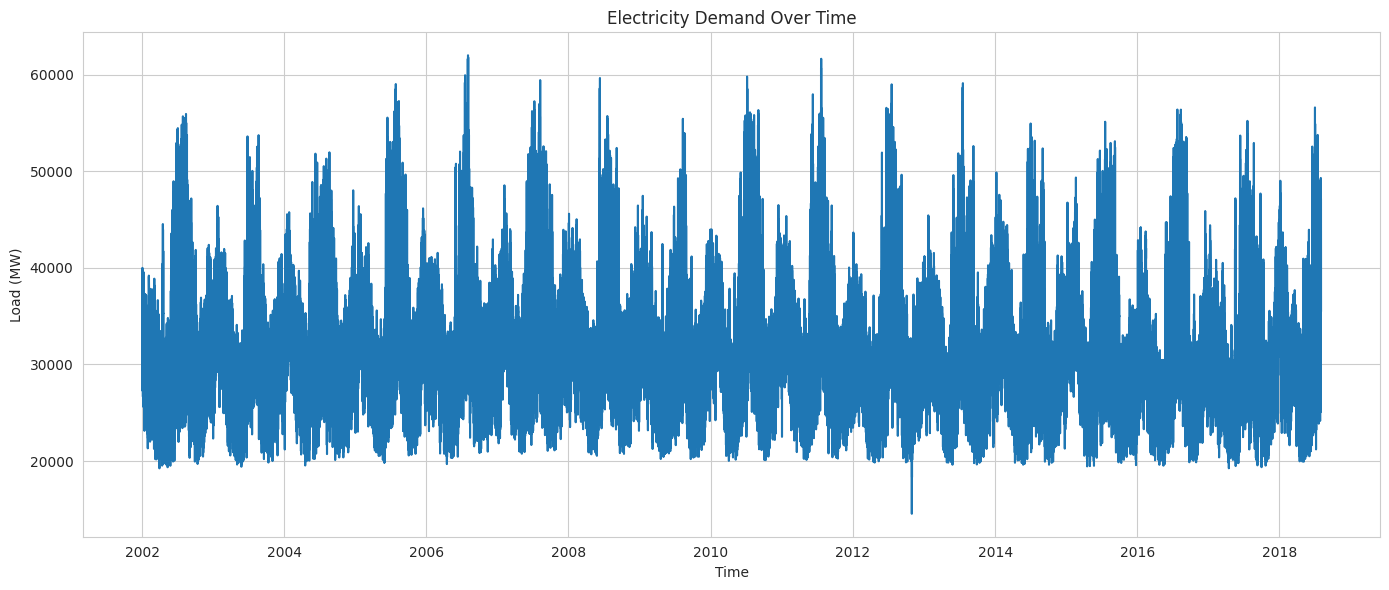

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(df["PJME_MW"])
plt.title("Electricity Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.tight_layout()
plt.show()

### Interpretation: Demand Over Time

The time series plot shows strong recurring seasonal and cyclical patterns in electricity demand. It also reveals occasional extreme peaks, which help explain why forecasting becomes more difficult during high-demand periods.

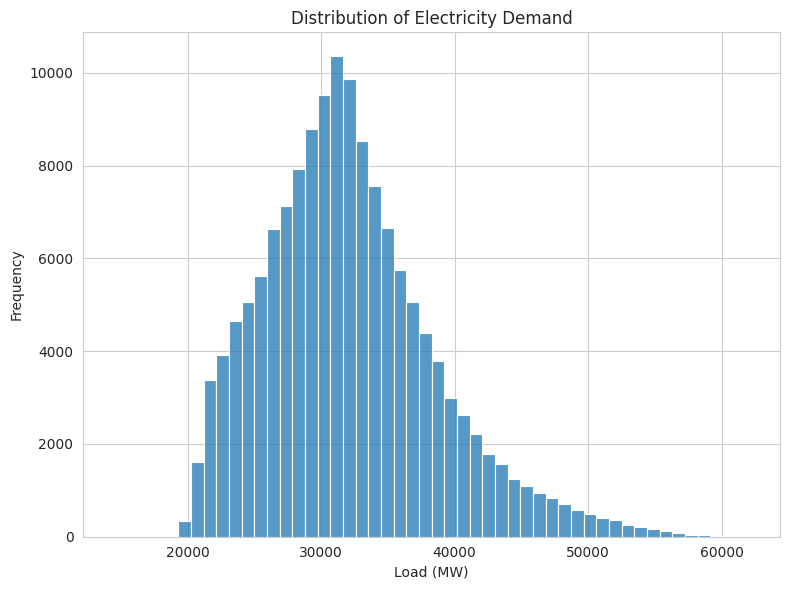

In [12]:
plt.figure(figsize=(8, 6))
sns.histplot(df["PJME_MW"], bins=50)
plt.title("Distribution of Electricity Demand")
plt.xlabel("Load (MW)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Interpretation: Demand Distribution

The demand distribution shows that most electricity load values fall within a central range, while extreme peaks occur less frequently. These peaks are operationally important because they are often associated with higher forecast error.

## Conclusion

This analysis demonstrates that forecast reliability is condition-dependent rather than uniform across time. Errors are highest during peak demand hours, summer periods, and high-demand regimes. Weekly structure also influences forecasting performance. ANOVA testing further supports that these differences are statistically significant. Overall, the findings show that evaluating forecast reliability requires more than a single aggregate accuracy metric.